In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.special import expit

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = "D:\data\ml"

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dasha\AppData\Local\Temp\ipykernel_11468\1672163289.py:22: SyntaxWarning: invalid escape sequence '\d'
  data_path = "D:\data\ml"


# Калибровка вероятностей

Часто при обучении моделей для бинарной классификации хочется получать не только предсказанную метку класса, но и вероятность положительного класса. Предсказанная вероятность может служить как мера уверенности нашего алгоритма. Также это позволяет сравнивать две модели, у которых одинаковые метрики точности. Этот тип метрик конкретно используется в высокорисковых приложениях, позволяя нам не рассматривать результаты модели как реальные вероятности, а вместо этого выходить за рамки необработанных результатов и предотвращать плохое принятие решений или ложную интерпретацию.

В задаче бинарной классификации откалиброванным алгоритмом называют такой алгоритм, для которого доля положительных примеров (на основе реальных меток классов) для предсказаний в окрестности произвольной вероятности $\hat p$ совпадает с этим значением $p$. Например, если взять объекты, для которых предсказанные вероятности близки к 0.7, то окажется, что среди них 70\% принадлежат положительному классу.
На математическом языке это выглядит так: если $\hat p$  — предсказанная вероятность класса 1, то $P(y=1|q(x_i)=\hat p)=\hat p$.

Однако некоторые алгоритмы не выдают корректные вероятности классов. В таком случае вероятности модели нужно калибровать.

Для визуализации откалиброванности алгоритма можно построить калибровочную кривую. На этой кривой абсцисса точки соответствуют значению $p$ (предсказаний алгоритма), а ордината соответствует доле примеров, для которых алгоритм предсказал вероятность, близкую к $p$. В идеальном случае эта кривая совпадает с прямой $y = x$. 

Чаще всего  $\hat p$ - это какие-то вещественные числа, которые будут разными для разных $y_i$. Для того, чтобы оценить именно вероятности, отрезок $[0, 1]$ можно разбить на бины, и для каждого бина вычислить долю класса 1 и,соответственно, среднюю предсказанную вероятность.

Пример диаграммы калибровки: 

![calib_1](../additional_materials/images/calib_1.png)


У идеально откалиброванной модели зеленая и розовая линии должны совпадать. Однако в нашем случае модель завышает свою оценку. Как отделить положительные примеры от отрицательных (дать дискретный класс)? Обычно пользуются порогом (логично сделать 0.5). Но нам придется сдвинуть порог вправо - так, чтобы разбить зеленый график пополам по вертикали.

Часто картинка иная. В таком случае говорят о слишком увернной модели (overconfident) или неуверенной (underconfident). В первом случае молдель предсказывает вероятности ближе к экстремальным, ченм стоит (0.1 вместо 0.2 и 0.9 вместо 0.1), во втором же наоборот, сводит все вероятности к центру интервала.

![calib_2](../additional_materials/images/calib_2.png)

Часто слишком большой уверенностью грешат нейросети, так как их учат именно на метках классов. Способ с этим бороться - Label smoothing, когда вместо метки класса модели дают слегка сглаженное значение (0.9 вместо 1, и т.д.). Альтернативный путь - hard samples mining, когда мы заставляем модель больше обращать внимания на объекты ближе к границе разделения.

Второй же случай возникает, если мы, наоборот, слишком сильно уделяем внимание границе. Это часто происходит в SVM или бэггинге.

Ниже на синтетическом примере посмотрим на типичные калибровочные кривые для overconfident и underconfident моделей: генерируем данные с нелинейной границей, получаем «предсказания» и искусственно искажаем их к экстремумам или к центру интервала. Кроме того, рассмотрим случай, когда модель предсказывает отношение классов, не зависящее от х.

In [3]:
from sklearn.datasets import make_moons

X_syn, y_syn = make_moons(n_samples=2000, noise=0.25, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.4, random_state=SEED)
clf_syn = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p_real = np.clip(clf_syn.predict_proba(X_te)[:, 1], 1e-6, 1 - 1e-6)

def logit(p: np.ndarray) -> np.ndarray:
    return np.log(p / (1 - p))
    
# to get new probabilities we need to make more strict logits and then return back to probas
p_over = 1. / (1 + np.exp(-5 * logit(p_real))) 
p_under = 0.5 + 0.35 * (p_real - 0.5)
p_constant = np.full_like(p_real, y_te.mean())

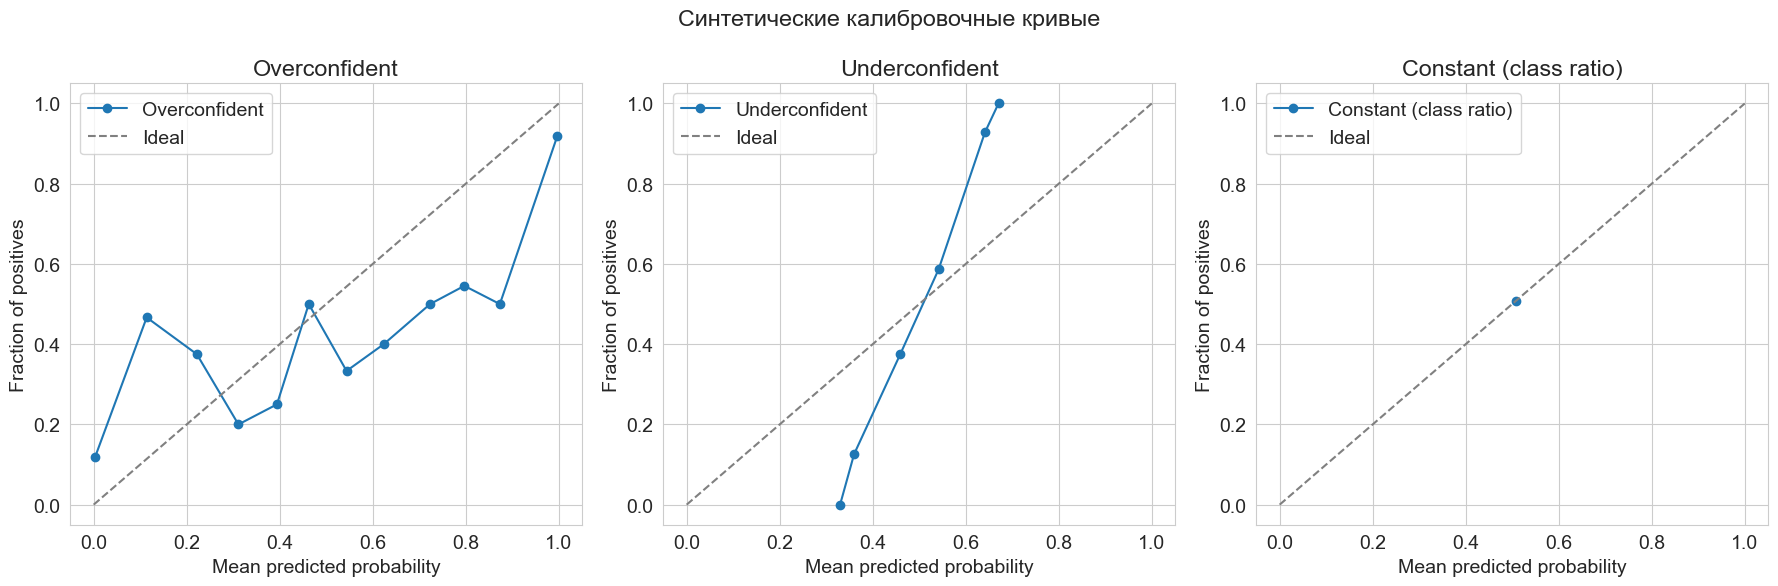

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, probs, label in zip(axs, [p_over, p_under, p_constant], ['Overconfident', 'Underconfident', 'Constant (class ratio)']):
    t, p = calibration_curve(y_te, probs, n_bins=12)
    ax.plot(p, t, marker='o', label=label)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(label)
    ax.legend()
plt.suptitle('Синтетические калибровочные кривые')
plt.tight_layout()
plt.show()

In [5]:
data = pd.read_csv('riceClassification.csv')


Отмасштабируем данные и подготовим трейн и тест.

In [6]:
X = data.drop(columns=['id', 'Class'])
y = data.Class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=999)
scaler = StandardScaler().fit(X_train, y_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

**Задание**: Оцените сбалансированность классов


Исходные данные:
Класс 0: 8200 объектов (45.09%)
Класс 1: 9985 объектов (54.91%)

Обучающая выборка:
Класс 0: 4916 объектов (45.06%)
Класс 1: 5995 объектов (54.94%)

Тестовая выборка:
Класс 0: 3284 объектов (45.15%)
Класс 1: 3990 объектов (54.85%)

Соотношение классов (0/1): 0.82
Вывод: классы умеренно несбалансированы


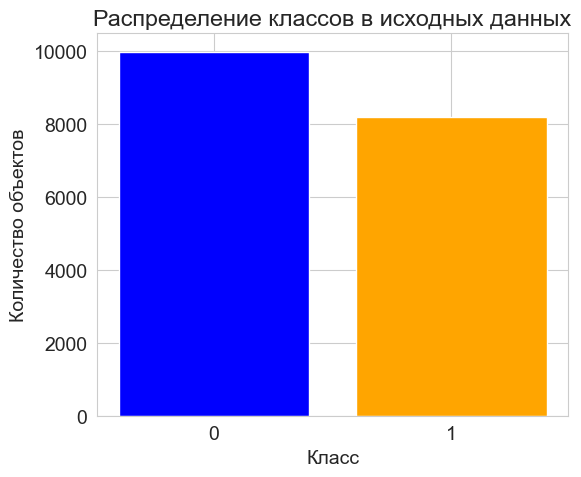

In [7]:
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("\nИсходные данные:")
print(f"Класс 0: {class_counts[0]} объектов ({class_percentages[0]:.2f}%)")
print(f"Класс 1: {class_counts[1]} объектов ({class_percentages[1]:.2f}%)")

train_counts = y_train.value_counts() if isinstance(y_train, pd.Series) else pd.Series(y_train).value_counts()
train_percentages = train_counts / len(y_train) * 100

print("\nОбучающая выборка:")
print(f"Класс 0: {train_counts[0]} объектов ({train_percentages[0]:.2f}%)")
print(f"Класс 1: {train_counts[1]} объектов ({train_percentages[1]:.2f}%)")

test_counts = y_test.value_counts() if isinstance(y_test, pd.Series) else pd.Series(y_test).value_counts()
test_percentages = test_counts / len(y_test) * 100

print("\nТестовая выборка:")
print(f"Класс 0: {test_counts[0]} объектов ({test_percentages[0]:.2f}%)")
print(f"Класс 1: {test_counts[1]} объектов ({test_percentages[1]:.2f}%)")

ratio = class_counts[0] / class_counts[1]
print(f"\nСоотношение классов (0/1): {ratio:.2f}")

if 0.9 <= ratio <= 1.1:
    print("Вывод: классы сбалансированы")
elif 0.7 <= ratio <= 1.3:
    print("Вывод: классы умеренно несбалансированы")
else:
    print("Вывод: классы сильно несбалансированы")


fig, axes = plt.subplots(1, 1, figsize=(6, 5))

axes.bar([0, 1], class_counts, color=['blue', 'orange'])
axes.set_xlabel('Класс')
axes.set_ylabel('Количество объектов')
axes.set_title('Распределение классов в исходных данных')
axes.set_xticks([0, 1])

plt.tight_layout()
plt.show()

Обучим метод опорных векторов (SVC — Support Vector Classification) и логистическую регрессию, в качестве метрики возьмем ROC-AUC. Для сравнения также посмотрим на градиентный бустинг.
В качестве скоров будем рассматривать выход decision_function. Этот метод возвращает confidence score для семплов и пропорционален расстоянию до разделяющей гиперплоскости, взятого со знаком. Он вернет матрицу размера (n_samples, n_classes). В бинарном случае, будет возвращен скор для класса 1.

Вопрос: Какая формула для decision function у логистической регрессии?

Ответ: для логистической регрессии decision function вычисляется как:    f(x) = w^T * x + b

где:
- w - вектор весов (коэффициентов)
- b - смещение
- x - вектор признаков объекта

это линейная комбинация признаков. затем эта функция передается в сигмоиду 
для получения вероятности:
    p(y=1|x) = 1 / (1 + exp(-f(x)))

таким образом, decision function - это значение до применения сигмоиды

In [8]:
svc = LinearSVC(max_iter=100000, C=0.1).fit(X_train, y_train)
svc_pred = svc.decision_function(X_test)
print('SVC ROC-AUC:', roc_auc_score(y_test, svc_pred))

SVC ROC-AUC: 0.9991453206707389


In [9]:
svc_pred

array([ 3.25919713,  1.95223252,  1.93751674, ...,  0.46630054,
        2.95728847, -1.77506552], shape=(7274,))

In [10]:
svc.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [11]:
print('SVC ROC-AUC (on predictions):', roc_auc_score(y_test, svc.predict(X_test)))

SVC ROC-AUC (on predictions): 0.9894067537906887


In [12]:
# метод опорных векторов
svc = LinearSVC(max_iter=100000, C=0.1, random_state=SEED)
svc.fit(X_train, y_train)
svc_pred = svc.decision_function(X_test)
print(f"SVC roc-auc: {roc_auc_score(y_test, svc_pred):.4f}")
print(f"SVC roc-auc (на метках классов): {roc_auc_score(y_test, svc.predict(X_test)):.4f}")

SVC roc-auc: 0.9991
SVC roc-auc (на метках классов): 0.9894


In [13]:
lr = LogisticRegression(max_iter=100000, C=0.1).fit(X_train, y_train)
lr_pred = lr.decision_function(X_test)
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, lr_pred))

Logistic regression ROC-AUC: 0.9990017675125695


In [14]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=SEED).fit(X_train, y_train)
gb_pred = gb.decision_function(X_test) # gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, gb_pred))

Gradient Boosting ROC-AUC: 0.9983573809676445


У случайного леса нет метода decision_function, поэтому просто посмотрим на точность.

In [15]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_pred))

Random Forest ROC-AUC: 0.9991008275866279


In [16]:
lr.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [17]:
lr.predict_proba(X_test)

array([[7.52180938e-05, 9.99924782e-01],
       [2.37484102e-03, 9.97625159e-01],
       [4.28557243e-03, 9.95714428e-01],
       ...,
       [1.72933989e-01, 8.27066011e-01],
       [2.10618110e-04, 9.99789382e-01],
       [9.98955458e-01, 1.04454161e-03]], shape=(7274, 2))

In [18]:
lr.classes_

array([0, 1])

Судя по метрикам, мы практически идеально предсказываем класс всеми моделями.

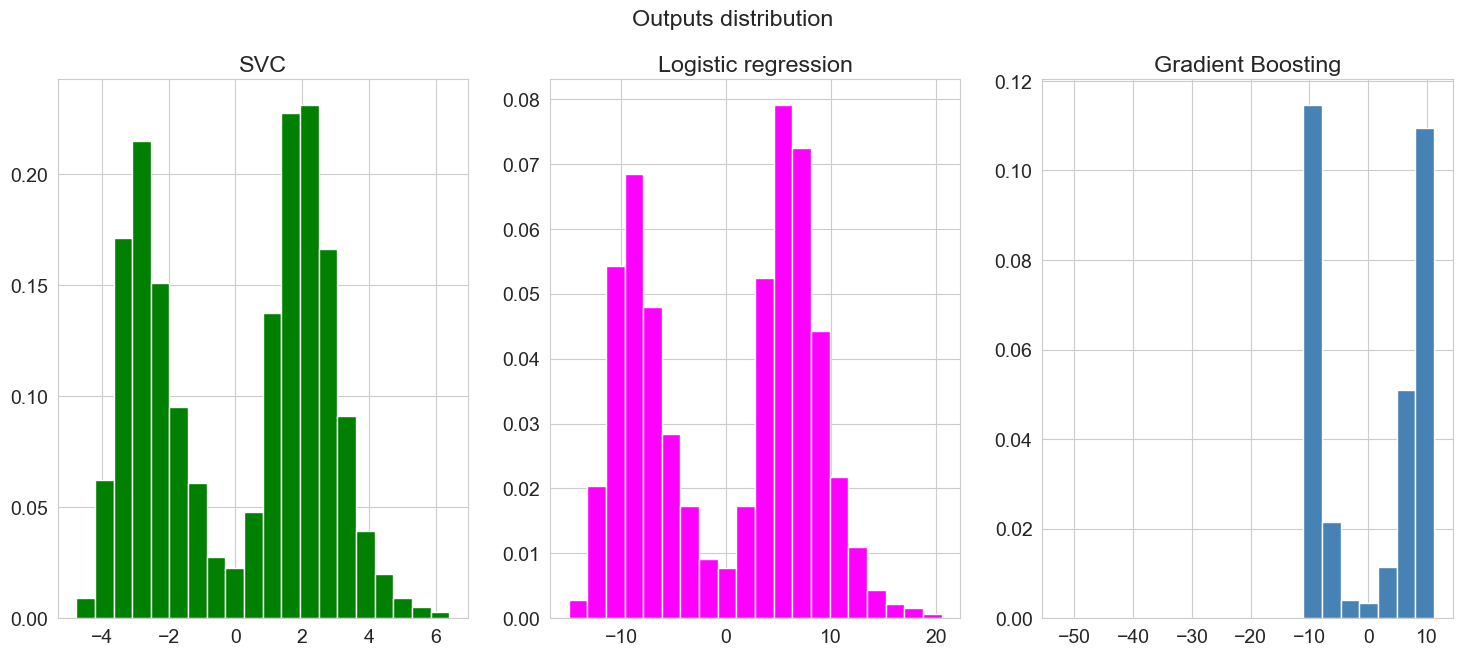

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(18, 7))

axs[0].hist(svc_pred, bins=20, color='green', density='True')
axs[1].hist(lr_pred, bins=20, color='magenta', density='True')
axs[2].hist(gb_pred, bins=20, color='steelblue', density='True')

axs[0].set_title('SVC')
axs[1].set_title('Logistic regression')
axs[2].set_title('Gradient Boosting')

plt.suptitle('Outputs distribution')
plt.show()

Мы видим, что скоры могут принимать любые вещественные значения. Но для оценивания вероятностей нам нужно перевести их в промежуток 
$[0,1]$. С логистической регрессией несложно: можно добавить сигмоиду или софтмакс, ведь модель и обучалась так, чтобы $\sigma (W^Tx)$
 приближало вероятности. Для SVC у нас нет такой опции, поэтому воспользуемся масштабированием через минимум-максимум.

Вопрос: а как вычисляются вероятности для бустинга?

Ответ: Для бинарной классификации в любом бустинге (градиентном, AdaBoost, XGBoost) вероятности вычисляются одинаково:

    1) Модель предсказывает логит (любое вещественное число)

    2) Логит преобразуется в вероятность через сигмоиду: p = 1 / (1 + exp(-logit))

In [20]:
svc_pred = (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())
lr_pred = lr.predict_proba(X_test)[:, 1]
gb_pred = gb.predict_proba(X_test)[:, 1]
rf_pred = rf.predict_proba(X_test)[:, 1]

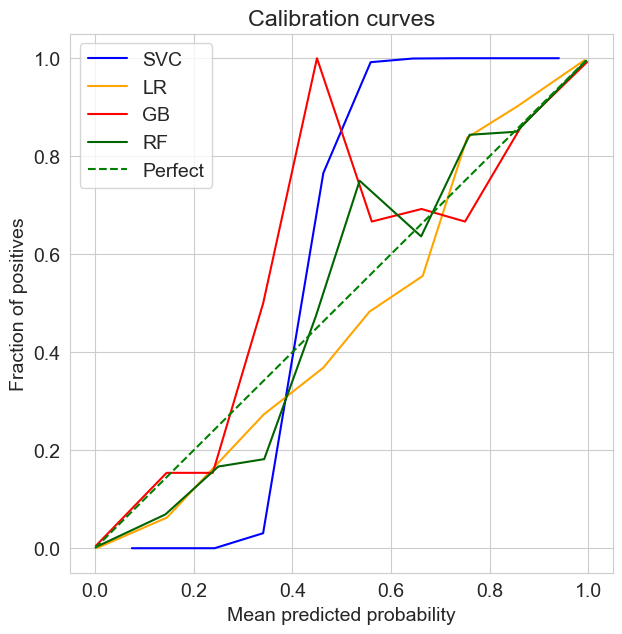

In [21]:
plt.figure(figsize=(7, 7))

svc_true_prob, svc_pred_prob = calibration_curve(y_test, svc_pred, n_bins=10)
lr_true_prob, lr_pred_prob = calibration_curve(y_test, lr_pred, n_bins=10)
gb_true_prob, gb_pred_prob = calibration_curve(y_test, gb_pred, n_bins=10)
rf_true_prob, rf_pred_prob = calibration_curve(y_test, rf_pred, n_bins=10)

plt.plot(svc_pred_prob, svc_true_prob, label='SVC', color='blue')
plt.plot(lr_pred_prob, lr_true_prob, label='LR', color='orange')
plt.plot(gb_pred_prob, gb_true_prob, label='GB', color='red')
plt.plot(rf_pred_prob, rf_true_prob, label='RF', color='darkgreen')
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='green')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves')
plt.legend()
plt.show()


Мы видим, что кривая для логистической регрессии неплохо приближает диагональ, при этом в бустинге можно вообразить чрезмерную уверенность. С SVC все гораздо хуже. Но попробуем откалибровать модели разными способами.

Что интересно с ансамблями: у них есть явный горб посередине интервала. Это значит, что моделям в принципе сложновато предсказывать крайние значения вероятностей. Хорошее объяснение этому дано в [статье](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf), цитата из нее: 
> Methods such as bagging and random forests that average predictions from a base set of models can have difficulty making predictions near 0 and 1 because variance in the underlying base models will bias predictions that should be near zero or one away from these values. Because predictions are restricted to the interval [0,1], errors caused by variance tend to be one-sided near zero and one. 

> For example, if a model should predict $p=0$ for a case, the only way bagging can achieve this is if all bagged trees predict zero. If we add noise to the trees that bagging is averaging over, this noise will cause some trees to predict values larger than 0 for this case, thus moving the average prediction of the bagged ensemble away from 0. We observe this effect most strongly with random forests because the base-level trees trained with random forests have relatively high variance due to feature subsetting.”

Другой способ визуализировать то же самое - диаграмма надёжности (reliability diagram):

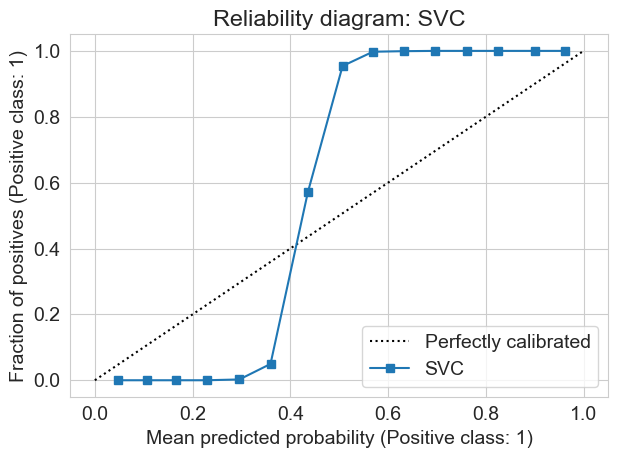

In [22]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, svc_pred, n_bins=15, name='SVC')
plt.title('Reliability diagram: SVC')
plt.tight_layout()
plt.show()

**Задание**: Постройте гистограмму предсказанных вероятностей для двух классификаторов.

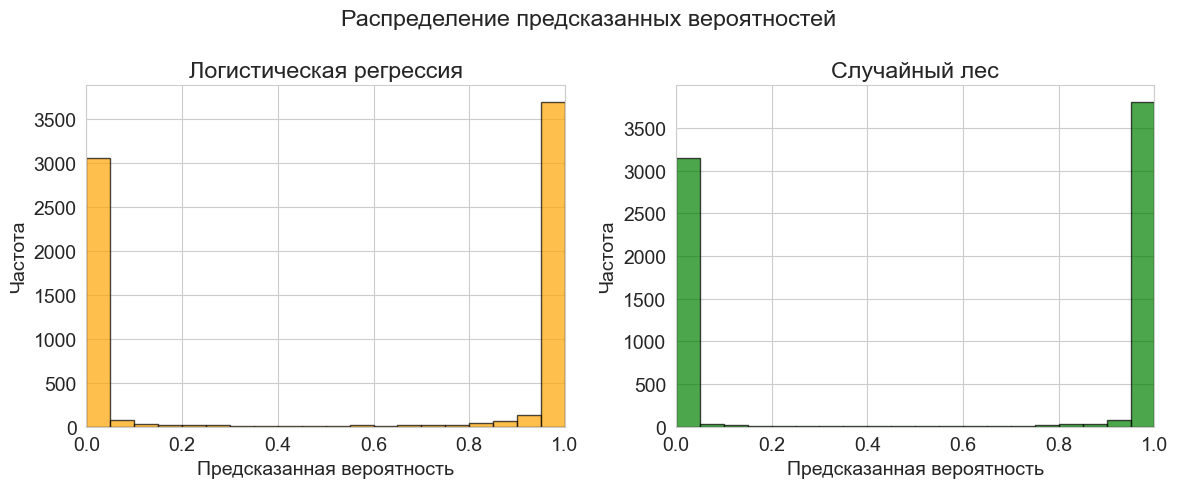

In [23]:
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(lr_probs, bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Предсказанная вероятность')
axes[0].set_ylabel('Частота')
axes[0].set_title('Логистическая регрессия')
axes[0].set_xlim(0, 1)

axes[1].hist(rf_probs, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Предсказанная вероятность')
axes[1].set_ylabel('Частота')
axes[1].set_title('Случайный лес')
axes[1].set_xlim(0, 1)

plt.suptitle('Распределение предсказанных вероятностей')
plt.tight_layout()
plt.show()

# Калибровка Платта
Пусть наш алгоритм выдаёт значения $f(x)$ (могут не быть вероятностями). Тогда итоговая вероятность строится как:

$$P(y = 1 | x) = \frac{1}{1+\exp (af(x) + b)},$$

где $a, b$ -- скалярные параметры. Эти параметры настраиваются методом максимума правдоподобия (минимизируя логистическую функцию потерь):
$$- \sum_{i=1}^N[y_i \log{(\sigma(af(x_i)+b))} + (1 - y_i) \log{(1-\sigma(af(x_i)+b))}] \to min_{a,b}$$

Алгоритм: на выходах $f(x)$ базовой модели обучается логистическая регрессия без регуляризации; откалиброванное предсказание — $\sigma(af(x)+b)$.

Вопрос: на какой выборке обучается модель?

Также Платт предложил для избежания переобучения изменить метки объектов в NLL ($y_i$ и $1-y_i$) на следующие значения:

$t_{+} = \frac{N_{+} + 1}{N_{-} + 2}$ для положительных примеров и

$t_{-} = \frac{1}{N_{-} + 2}$ для отрицательных, где $N_{-}$ и $N_{+}$ число негативных и позитивных семплов в выборке. 

Калибровку Платта можно представить как применение логистической регрессии поверх предсказаний другого алгоритма с отключенной регуляризацией. 

Калибровка Платта неплохо справляется с SVM, но для более хитрых классификаторов может спасовать. В целом, можно показать, что этот метод хорошо работает, если для каждого из истинных классов предсказанные вероятности распределены нормально с одинаковыми дисперсиями (подробнее [здесь](https://research-information.bris.ac.uk/ws/portalfiles/portal/154625753/Full_text_PDF_final_published_version_.pdf)). 

Вообще эта калибровка относится к большой группе параметрических методов калибрации, туда же относится бета-калибрация (в предположении бета-распределения) или калибрация Дирихле (для мультикласса). 

In [24]:
sigmoid_svc = CalibratedClassifierCV(svc, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_svc_pred = sigmoid_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, sigmoid_svc_pred))

SVC ROC-AUC: 0.9991337204155334


In [25]:
sigmoid_lr = CalibratedClassifierCV(lr, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_lr_pred = sigmoid_lr.predict_proba(X_test)[:, 1]
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, sigmoid_lr_pred))

Logistic regression ROC-AUC: 0.9989783380497528


In [26]:
sigmoid_rf = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_rf_pred = sigmoid_rf.predict_proba(X_test)[:, 1]
print('LRandom forest ROC-AUC:', roc_auc_score(y_test, sigmoid_rf_pred))

LRandom forest ROC-AUC: 0.999082664029135


In [27]:
sigmoid_gb = CalibratedClassifierCV(gb, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_gb_pred = sigmoid_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, sigmoid_gb_pred))

Gradient Boosting ROC-AUC: 0.9990612569792324


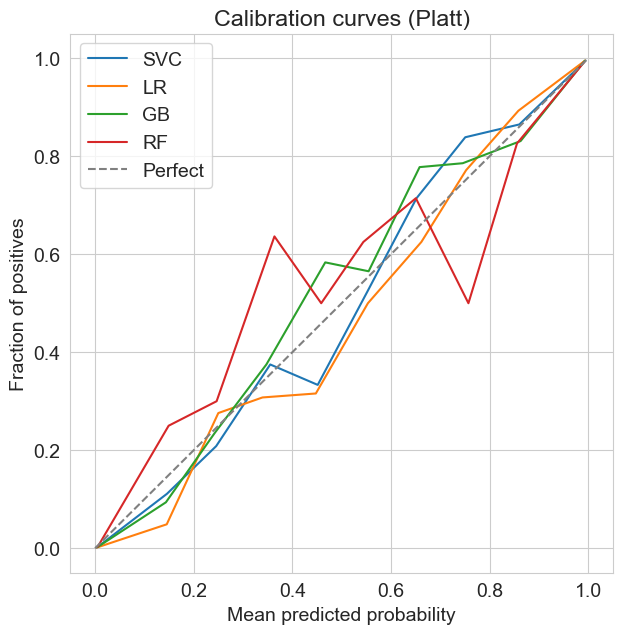

In [28]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Platt)')
plt.legend()
plt.show()

Как мы видим, калибровка Платта действительно улучшила вероятности, который получаются у SVC, RF и GB. При этом кривая для логистической регрессии практически не сдвигается. 

# Изотоническая регрессия
В этом методе также строится отображение из предсказаний модели в откалиброванные вероятности. Используется изотоническая функция: неубывающая, кусочно-постоянная; $x$ — выходы алгоритма, $y$ — целевая переменная. 

Мы хотим найти такую функцию $m(t)$: $P(y = 1 | x) = m(f(x))$. Она настраивается под квадратичную ошибку:

$$m = \arg \min_{z} \sum (y_i - z(f(x_i))^2,$$

с помощью специального алгоритма (Pool-Adjacent-Violators Algorithm):

---
*Вход: обучающая выборка — пары (скор модели $f_i$, метка $y_i \in \{0,1\}$), отсортированные по возрастанию $f_i$.*

Для каждой точки $i$ задаём один сегмент: оценка вероятности сегмента $m_{i,i} = y_i$ (метка точки), вес сегмента $w_{i,i} = 1$.

В цикле, пока есть нарушение изотонности — два соседних сегмента $(k, i-1)$ и $(i, l)$, у которых $m_{k,i-1} \geq m_{i,l}$ — объединяем их в один $(k, l)$: новый вес $w_{k,l} = w_{k,i-1} + w_{i,l}$, новая оценка $m_{k,l} = (w_{k,i-1} m_{k,i-1} + w_{i,l} m_{i,l}) / w_{k,l}$; заменяем два старых сегмента одним и повторяем.

*Выход: кусочно-постоянная функция $m(f)$: для любого скора $f$ значение $m(f)$ — это $m_{i,j}$ того сегмента $(i,j)$, в диапазон которого попадает $f$.*

---

В результате калибровки получаем надстройку над нашей моделью, которая применяется поверх предсказаний базовой модели. В случае мультиклассовой классификации каждый класс калибруется отдельно против остальных (one-versus-all), вероятности при предсказании нормируются.

Этот метод более общий, чем калибровка Платта, так как единственное условие для калибровочной функции - чтобы она была изотонической. Этот метод склонен к переобучению, поэтому его рекомендуется применять только для больших выборок.


In [29]:
isotonic_svc = CalibratedClassifierCV(svc, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_svc_pred = isotonic_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

SVC ROC-AUC: 0.9990992249197903


In [30]:
isotonic_lr = CalibratedClassifierCV(lr, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_lr_pred = isotonic_lr.predict_proba(X_test)[:, 1]
print('LR ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

LR ROC-AUC: 0.9990992249197903


In [31]:
isotonic_gb = CalibratedClassifierCV(gb, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_gb_pred = isotonic_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, isotonic_gb_pred))

Gradient Boosting ROC-AUC: 0.998995204210282


In [32]:
isotonic_rf = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf_pred = isotonic_rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, isotonic_rf_pred))

Random Forest ROC-AUC: 0.9991284163514756


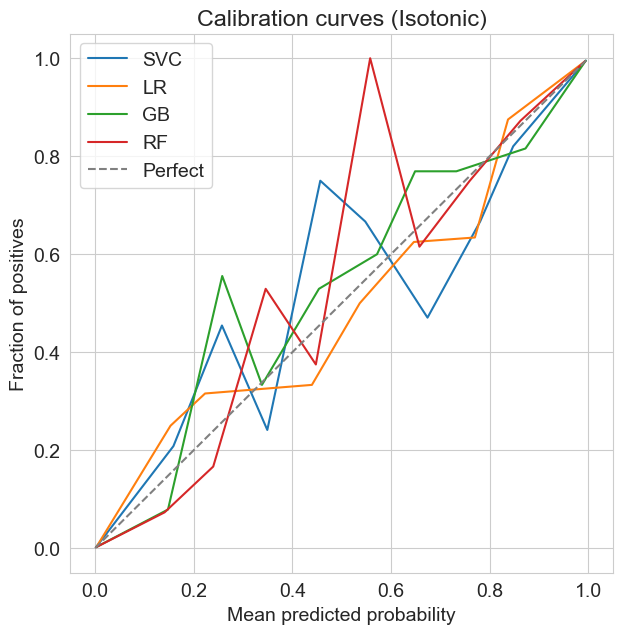

In [33]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', isotonic_svc_pred), ('LR', isotonic_lr_pred), ('GB', isotonic_gb_pred), ('RF', isotonic_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Isotonic)')
plt.legend()
plt.show()

Изотоническая регрессия немного подпортила кривую калибрации для моделей. Судя по всему, она переобучилась.

## Мультикласс
У нас есть как минимум три варианта определить, что означает мультиклассовая калиброванность. Например, по мере увеличения строгости:
1) Учитывать только самую высокую вероятность. Для него мы требуем, чтобы среди всех случаев, где вероятность наиболее вероятного класса прогнозируется как $c$, ожидаемая точность была бы $c$. $P(Y=i|\hat p_i(x)=q_i)=q_i, i=\arg\max_j \hat p_j (X)$
2) Учитывать маргинальные вероятности. Тут мы хотим, чтобы все one-vs-rest вероятности были откалиброваны: $P(Y=i|\hat p_i(x)=q_i)=q_i, i=1...k$.
3) Учитывать весь вектор вероятностей. Т.е. чтобы пропорции классов для семплов с определенным вектором предсказаний былит такие же, как и весь вектор предсказаний:  $P(Y=i|\hat p(x)=q)=q_i, i=1...k$. 
   
Чаще всего используется определение слабой калиброванности (1). Однако, в случае чувствительной к стоимости постановки задачи оно может быть слишком слабым.


## Оценка качества калибровки

Мы что-то поняли по графикам, но как оценить численно улучшение предсказания вероятностей? Для этого есть свои метрики.

**Maximum calibration error**. Самый простой способ, впрочем — он наследник идеи с калибровочной кривой. А именно, разобьём отрезок 
$[0,1]$ на бины $B_1, B_2, ..., B_k$ по предсказанным вероятностям $\overline y(x_i)$ и вычислим следующее:
$$ \max_{j=1,..,k}|{\overline y(B_k) - \overline q (B_k) }|$$
Где $\overline y(B_k) $ - средняя предсказанная вероятность, $ \overline q (B_k) $ - среднее значение уверенности.

**Expected Calibration Error (ECE)** считает среднюю разницу: $$ \sum^k_{j=1}{{\|B_j\|}\over{N}}{| {\overline y(B_k) - \overline q (B_k) }|},$$
где $\|B_j\|$ - число семплов в бине. Бинны обычно строят равными по длине отрезка $[0,1]$ (uniform) или по квантилям предсказаний (quantile); веса $|B_j|/N$ делают вклад каждого бина пропорциональным его размеру.

Проблема этих способов в том, что мы можем очень по-разному предсказывать в каждом из бинов вероятности (в том числе константой) без ущерба для метрики.

Применим метрику калибрации:

In [34]:
def binary_ECE(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= low) & (y_prob <= high) if i == n_bins - 1 else (y_prob >= low) & (y_prob < high)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * np.abs(acc - conf)
    return ece / n

print("Platt:")
print('SVC binary-ECE = ', binary_ECE(y_test, sigmoid_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, sigmoid_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, sigmoid_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, sigmoid_rf_pred))

print("Isotonic:")
print('SVC binary-ECE = ', binary_ECE(y_test, isotonic_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, isotonic_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, isotonic_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, isotonic_rf_pred))

Platt:
SVC binary-ECE =  0.0027822956798889934
Linear binary-ECE =  0.0034477460600426638
GB binary-ECE =  0.003472623806893145
RF binary-ECE =  0.002610568433671964
Isotonic:
SVC binary-ECE =  0.0020864508068445986
Linear binary-ECE =  0.002150623426981368
GB binary-ECE =  0.002283717139315842
RF binary-ECE =  0.002056138427129562


Может быть такое, что метрики показывают нам иную картину, чем графики. Возможно, дело в том, что мы делали графики без учета числа семплов в бинах (а резкие прыжки могут значить, что семплов маловато). 

**Задание**: постройте калибровочные кривые для адаптивных бинов (strategy=‘quantile’) и сравните графики для разных калибровок с ними.

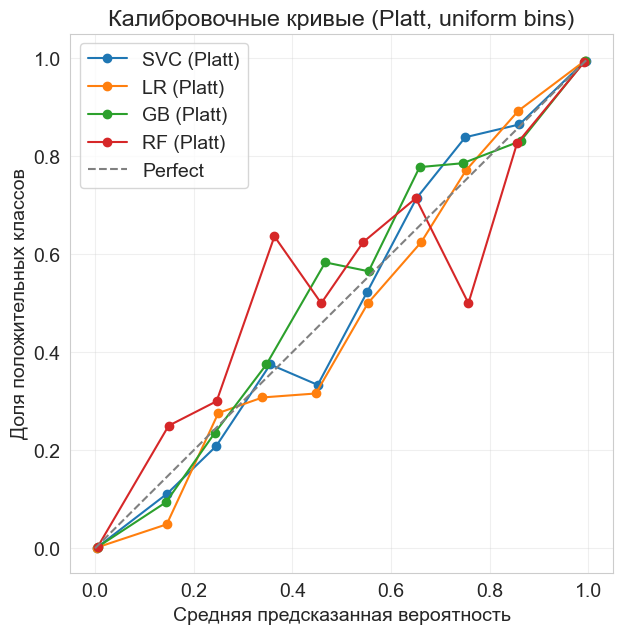

In [35]:
plt.figure(figsize=(7, 7))

for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    frac_pos, mean_pred = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o', label=f'{name} (Platt)')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных классов')
plt.title('Калибровочные кривые (Platt, uniform bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

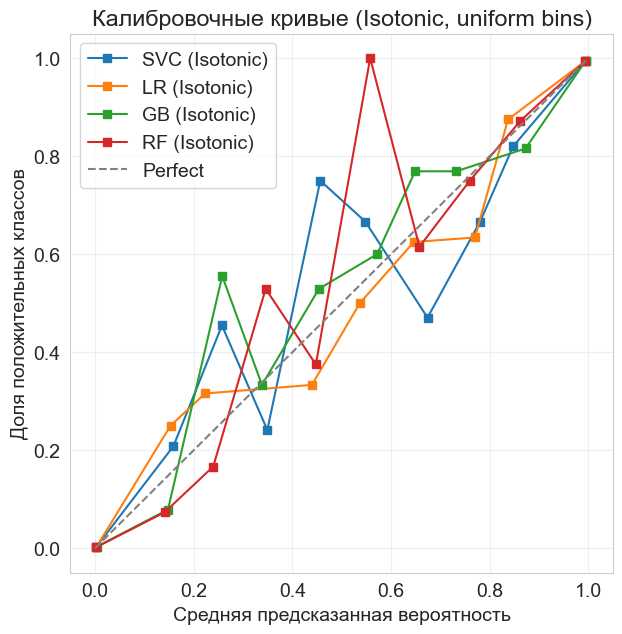

In [36]:
plt.figure(figsize=(7, 7))

for name, pred in [('SVC', isotonic_svc_pred), ('LR', isotonic_lr_pred), ('GB', isotonic_gb_pred), ('RF', isotonic_rf_pred)]:
    frac_pos, mean_pred = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='s', label=f'{name} (Isotonic)')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных классов')
plt.title('Калибровочные кривые (Isotonic, uniform bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [37]:
def calculate_ece(y_true, y_prob, n_bins=10, strategy='uniform'):
    if strategy == 'uniform':
        bin_edges = np.linspace(0, 1, n_bins + 1)
    else:
        bin_edges = np.quantile(y_prob, np.linspace(0, 1, n_bins + 1))
        bin_edges[0] = 0
        bin_edges[-1] = 1
    
    ece = 0.0
    n = len(y_true)
    
    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= low) & (y_prob <= high)
        else:
            mask = (y_prob >= low) & (y_prob < high)
        
        if mask.sum() == 0:
            continue
        
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * np.abs(acc - conf)
    
    return ece / n

svc_raw_proba = svc_pred
lr_proba = lr.predict_proba(X_test)[:, 1]
gb_proba = gb.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

print("ece для неоткалиброванных моделей (uniform bins):")
print(f"SVC (raw, scaled): {calculate_ece(y_test, svc_raw_proba, strategy='uniform'):.4f}")
print(f"Logistic Regression: {calculate_ece(y_test, lr_proba, strategy='uniform'):.4f}")
print(f"Gradient Boosting: {calculate_ece(y_test, gb_proba, strategy='uniform'):.4f}")
print(f"Random Forest: {calculate_ece(y_test, rf_proba, strategy='uniform'):.4f}")

print("\nece для неоткалиброванных моделей (quantile bins):")
print(f"SVC (raw, scaled): {calculate_ece(y_test, svc_raw_proba, strategy='quantile'):.4f}")
print(f"Logistic Regression: {calculate_ece(y_test, lr_proba, strategy='quantile'):.4f}")
print(f"Gradient Boosting: {calculate_ece(y_test, gb_proba, strategy='quantile'):.4f}")
print(f"Random Forest: {calculate_ece(y_test, rf_proba, strategy='quantile'):.4f}")

print("\nece для откалиброванных моделей (Platt, uniform bins):")
print(f"SVC (Platt): {calculate_ece(y_test, sigmoid_svc_pred, strategy='uniform'):.4f}")
print(f"LR (Platt): {calculate_ece(y_test, sigmoid_lr_pred, strategy='uniform'):.4f}")
print(f"GB (Platt): {calculate_ece(y_test, sigmoid_gb_pred, strategy='uniform'):.4f}")
print(f"RF (Platt): {calculate_ece(y_test, sigmoid_rf_pred, strategy='uniform'):.4f}")

ece для неоткалиброванных моделей (uniform bins):
SVC (raw, scaled): 0.2853
Logistic Regression: 0.0066
Gradient Boosting: 0.0056
Random Forest: 0.0026

ece для неоткалиброванных моделей (quantile bins):
SVC (raw, scaled): 0.2593
Logistic Regression: 0.0039
Gradient Boosting: 0.0022
Random Forest: 0.0011

ece для откалиброванных моделей (Platt, uniform bins):
SVC (Platt): 0.0028
LR (Platt): 0.0034
GB (Platt): 0.0035
RF (Platt): 0.0026


**Вопрос**: Как можно адаптировать MCE/ECE для мультиклассовой задачи? Напишите формулы.
*Ответ*: использовать выигравший класс. Можно сделать бинарные есе для всех классов и потом усреднить по классам.

**Ответ**: Для мультиклассовой задачи ece можно адаптировать несколькими способами. Самый популярный способ - top-label ece, при котором рассматривается только самый вероятный класс, то есть берется предсказание модели с максимальной вероятностью и сравнивается с тем, угадала ли модель правильный класс. Второй способ - marginal ece, который применяет подход one-vs-rest для каждого класса: для каждого класса отдельно строится бинарная задача "этот класс против всех остальных", и ece усредняется по всем классам. Третий способ - classwise ece, который также усредняет ошибку калибровки по всем классам, но с учетом количества объектов каждого класса.

В случае мультикласса, у нас возникает несколько сложностей: во-первых, в случае большого числа классов число бинов будет очень большим, при этом многие будут пустыми. Да и само определение реальной ECE пока не сделано. 

**Задание:** посчитайте ECE для модели, которая предсказывает пропорцию классов. Какие знаечения ECE и лосса у нее будут? Что изменится, если модель начнет предсказывать 0.9 для позитивных семплов и продолжит предсказывать пропорцию классов для негадивных?

In [38]:
from sklearn.metrics import log_loss

class_ratio = y_train.mean()
print(f"Пропорция класса 1 в обучающей выборке: {class_ratio:.4f}")

constant_pred = np.full_like(y_test, class_ratio, dtype=float)

ece_constant = calculate_ece(y_test, constant_pred, strategy='uniform')
print(f"ece для модели, предсказывающей пропорцию классов: {ece_constant:.4f}")

ll_constant = log_loss(y_test, constant_pred)
print(f"log loss для константной модели: {ll_constant:.4f}")

y_pred_mixed = np.where(y_test == 1, 0.9, class_ratio)

ece_mixed = calculate_ece(y_test, y_pred_mixed, strategy='uniform')
print(f"\nece для модели (0.9 для позитивных, {class_ratio:.2f} для негативных): {ece_mixed:.4f}")

ll_mixed = log_loss(y_test, y_pred_mixed)
print(f"log loss: {ll_mixed:.4f}")

print(f"\nчто изменилось:")
print(f"ece: {ece_constant:.4f} -> {ece_mixed:.4f}")
print(f"log loss: {ll_constant:.4f} -> {ll_mixed:.4f}")

Пропорция класса 1 в обучающей выборке: 0.5494
ece для модели, предсказывающей пропорцию классов: 0.0009
log loss для константной модели: 0.6884

ece для модели (0.9 для позитивных, 0.55 для негативных): 0.3029
log loss: 0.4177

что изменилось:
ece: 0.0009 -> 0.3029
log loss: 0.6884 -> 0.4177


**Вывод**: модель стала менее калиброванной (хуже ECE), но лучше различает классы. 

Можно посчитать калиброванность и на уровне семплов.

**Brier score.** Тоже одна из популярных метрик, которая попросту измеряет разницу между предсказанными вероятностями и $ y_i $ (обратите внимание, что $ y_i $  - это либо 0, либо 1):
$$ \sum^N_{i=1}(y_i - q (x_i))^2,$$ 
для бинарного случая, и
$$ {1 \over N} \sum^N_{n=1}\sum^K_{j=1} (I(y_n=j) - q_{nj})^2,$$ 
для мультикласса.

**Вопрос**: Какое значение соответствует лучшей калибрации? Какие максимальные и минимальные значения он можеит принимать?

**Ответ**: brier score измеряет среднеквадратичную ошибку между предсказанными вероятностями и истинными метками (0 или 1).

Лучшая калибровка соответствует наименьшему значению brier score.

Минимальное значение: 0
Это достигается, когда модель идеально предсказывает вероятности: для всех объектов с y=1 предсказано 1, с y=0 предсказано 0.

Максимальное значение: 1
Это достигается, когда модель постоянно ошибается: для всех объектов с y=1 предсказано 0, с y=0 предсказано 1.

Также можно использовать log-loss:
$$ {-1\over N} {\sum^N_{n=1}\sum^K_{j=1}I(y_n=j)log(q_{n,j})}$$

Для достаточно гладких классификатора и датасета brier score и log-loss будут адекватными средствами оценки, но если нет — возможно всякое.

In [39]:
print('Log-loss (ниже — лучше):')
print('Platt SVC =', log_loss(y_test, np.column_stack([1 - sigmoid_svc_pred, sigmoid_svc_pred])))
print('Platt LR =', log_loss(y_test, np.column_stack([1 - sigmoid_lr_pred, sigmoid_lr_pred])))
print('Platt GB =', log_loss(y_test, np.column_stack([1 - sigmoid_gb_pred, sigmoid_gb_pred])))
print('Platt RF =', log_loss(y_test, np.column_stack([1 - sigmoid_rf_pred, sigmoid_rf_pred])))
print('Isotonic SVC =', log_loss(y_test, np.column_stack([1 - isotonic_svc_pred, isotonic_svc_pred])))
print('Isotonic LR =', log_loss(y_test, np.column_stack([1 - isotonic_lr_pred, isotonic_lr_pred])))
print('Isotonic GB =', log_loss(y_test, np.column_stack([1 - isotonic_gb_pred, isotonic_gb_pred])))
print('Isotonic RF =', log_loss(y_test, np.column_stack([1 - isotonic_rf_pred, isotonic_rf_pred])))

Log-loss (ниже — лучше):
Platt SVC = 0.031276285531666545
Platt LR = 0.0333262455198998
Platt GB = 0.03331647881716411
Platt RF = 0.038908642002126646
Isotonic SVC = 0.030862017939829182
Isotonic LR = 0.033625055910619976
Isotonic GB = 0.03191541409933446
Isotonic RF = 0.0317766445159259


In [40]:
print("Platt:")
print('SVC brier score = ', brier_score_loss(y_test, sigmoid_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, sigmoid_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, sigmoid_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, sigmoid_rf_pred, pos_label=1))

print("Isotonic:")
print('SVC brier score = ', brier_score_loss(y_test, isotonic_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, isotonic_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, isotonic_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, isotonic_rf_pred, pos_label=1))

Platt:
SVC brier score =  0.008190798964847236
Linear brier score =  0.008657533565358946
GB brier score =  0.008325371462496654
RF brier score =  0.008416712034272293
Isotonic:
SVC brier score =  0.008210667087880846
Linear brier score =  0.008753390327467456
GB brier score =  0.008318772289237032
RF brier score =  0.008147859165350083


**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [41]:
from sklearn.metrics import brier_score_loss, log_loss

print("неоткалиброванные модели:")

svc_raw_brier = brier_score_loss(y_test, svc_raw_proba)
svc_raw_logloss = log_loss(y_test, svc_raw_proba)
print(f"SVC (raw, scaled): brier = {svc_raw_brier:.6f}, log_loss = {svc_raw_logloss:.6f}")

lr_brier = brier_score_loss(y_test, lr_proba)
lr_logloss = log_loss(y_test, lr_proba)
print(f"Logistic Regression: brier = {lr_brier:.6f}, log_loss = {lr_logloss:.6f}")

gb_brier = brier_score_loss(y_test, gb_proba)
gb_logloss = log_loss(y_test, gb_proba)
print(f"Gradient Boosting: brier = {gb_brier:.6f}, log_loss = {gb_logloss:.6f}")

rf_brier = brier_score_loss(y_test, rf_proba)
rf_logloss = log_loss(y_test, rf_proba)
print(f"Random Forest: brier = {rf_brier:.6f}, log_loss = {rf_logloss:.6f}")

print("\nоткалиброванные модели (Platt):")
print(f"SVC (Platt): brier = {brier_score_loss(y_test, sigmoid_svc_pred):.6f}, log_loss = {log_loss(y_test, sigmoid_svc_pred):.6f}")
print(f"LR (Platt): brier = {brier_score_loss(y_test, sigmoid_lr_pred):.6f}, log_loss = {log_loss(y_test, sigmoid_lr_pred):.6f}")
print(f"GB (Platt): brier = {brier_score_loss(y_test, sigmoid_gb_pred):.6f}, log_loss = {log_loss(y_test, sigmoid_gb_pred):.6f}")
print(f"RF (Platt): brier = {brier_score_loss(y_test, sigmoid_rf_pred):.6f}, log_loss = {log_loss(y_test, sigmoid_rf_pred):.6f}")

неоткалиброванные модели:
SVC (raw, scaled): brier = 0.103584, log_loss = 0.368520
Logistic Regression: brier = 0.008709, log_loss = 0.034384
Gradient Boosting: brier = 0.008841, log_loss = 0.045925
Random Forest: brier = 0.008120, log_loss = 0.031454

откалиброванные модели (Platt):
SVC (Platt): brier = 0.008191, log_loss = 0.031276
LR (Platt): brier = 0.008658, log_loss = 0.033326
GB (Platt): brier = 0.008325, log_loss = 0.033316
RF (Platt): brier = 0.008417, log_loss = 0.038909


Итак, мы откалибровали наши классификаторы. Теперь мы можем оценить, как поменяются метрики после этого. Так, по идее точность, f1 не должны сильно поменяться, так как вблизи от границы разделения вероятности не должны сильно измениться. Так ли это?
Теперь **вопрос**: Изменится ли после калибрации ROC-AUC и как? Можете ли вы ответить на вопрос без измерений?

**Ответ**: roc-auc не изменится после калибровки, потому что roc-auc зависит только от порядка предсказаний (ранжирования), а не от их абсолютных значений.

**Задание**: Обучите дерево решений и случайный лес.

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)
dt_pred = dt.predict_proba(X_test)[:, 1]
dt_roc_auc = roc_auc_score(y_test, dt_pred)
dt_accuracy = accuracy_score(y_test, dt.predict(X_test))
dt_f1 = f1_score(y_test, dt.predict(X_test))

print("дерево решений:")
print(f"roc-auc: {dt_roc_auc:.4f}")
print(f"accuracy: {dt_accuracy:.4f}")
print(f"f1 score: {dt_f1:.4f}")

rf_new = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
rf_new.fit(X_train, y_train)
rf_new_pred = rf_new.predict_proba(X_test)[:, 1]
rf_new_roc_auc = roc_auc_score(y_test, rf_new_pred)
rf_new_accuracy = accuracy_score(y_test, rf_new.predict(X_test))
rf_new_f1 = f1_score(y_test, rf_new.predict(X_test))

print("\nслучайный лес:")
print(f"roc-auc: {rf_new_roc_auc:.4f}")
print(f"accuracy: {rf_new_accuracy:.4f}")
print(f"f1 score: {rf_new_f1:.4f}")

дерево решений:
roc-auc: 0.9838
accuracy: 0.9839
f1 score: 0.9853

случайный лес:
roc-auc: 0.9991
accuracy: 0.9904
f1 score: 0.9913


**Задание**: Откалибройте изотоническим методом. Постройте калибровочные кривые для классификаторов, до и после калибровки.

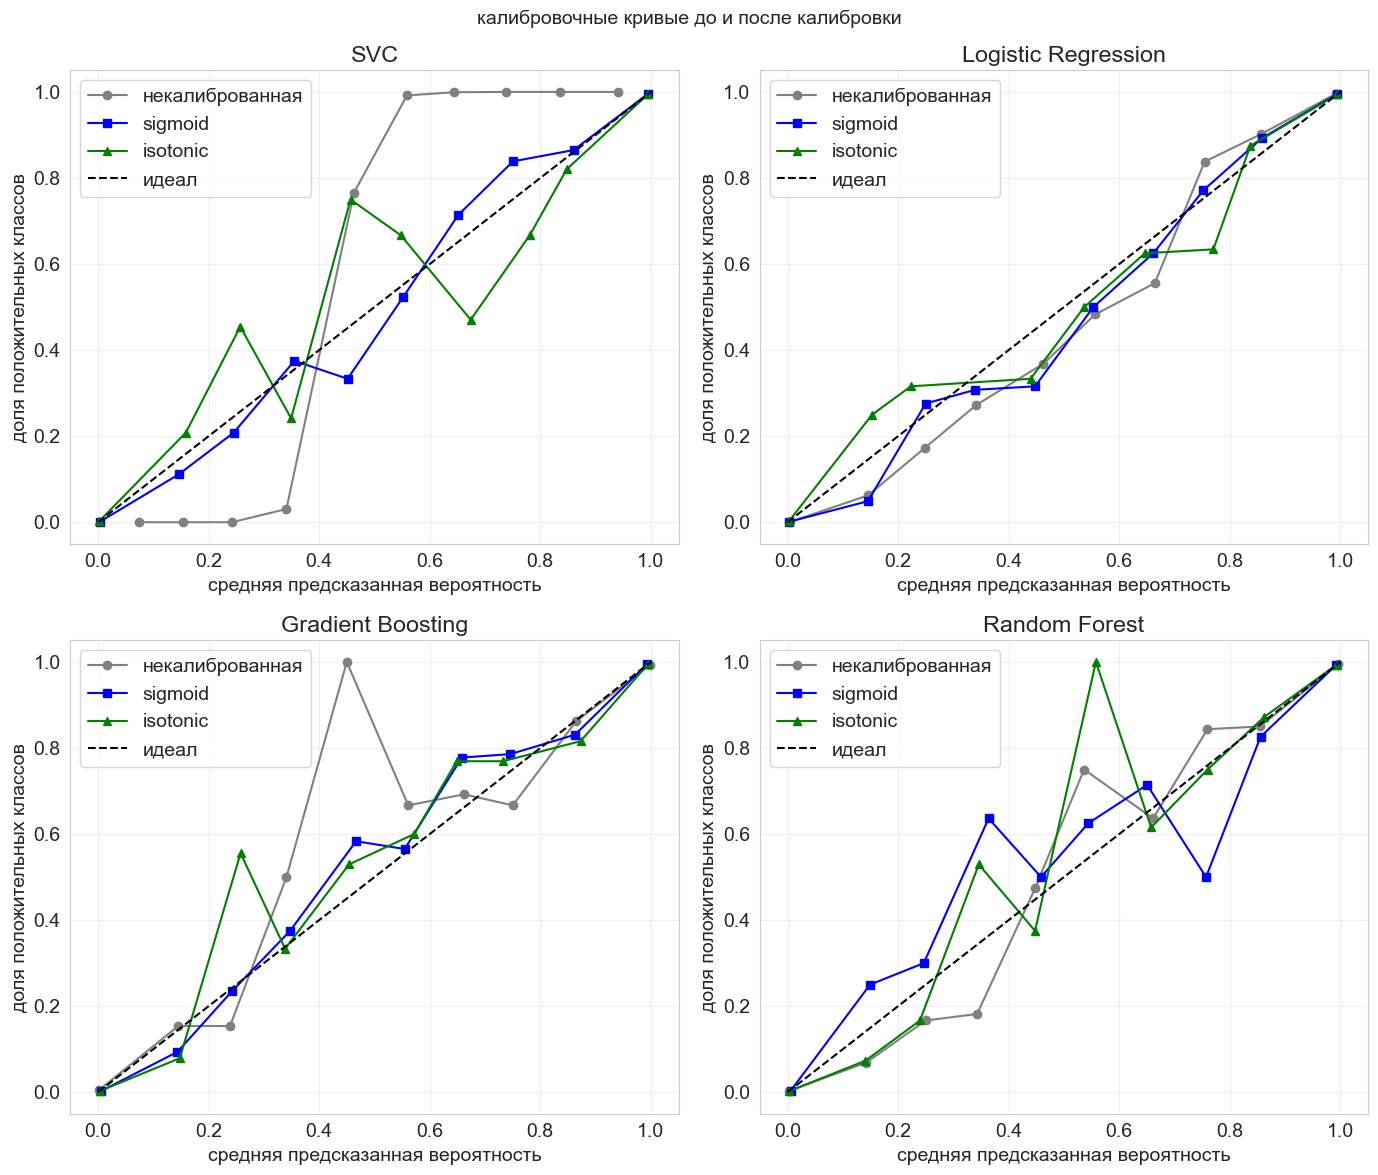

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

isotonic_svc = CalibratedClassifierCV(svc, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_lr = CalibratedClassifierCV(lr, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_gb = CalibratedClassifierCV(gb, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)

sigmoid_svc = CalibratedClassifierCV(svc, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_lr = CalibratedClassifierCV(lr, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_gb = CalibratedClassifierCV(gb, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_rf = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)

isotonic_svc_pred = isotonic_svc.predict_proba(X_test)[:, 1]
isotonic_lr_pred = isotonic_lr.predict_proba(X_test)[:, 1]
isotonic_gb_pred = isotonic_gb.predict_proba(X_test)[:, 1]
isotonic_rf_pred = isotonic_rf.predict_proba(X_test)[:, 1]

sigmoid_svc_pred = sigmoid_svc.predict_proba(X_test)[:, 1]
sigmoid_lr_pred = sigmoid_lr.predict_proba(X_test)[:, 1]
sigmoid_gb_pred = sigmoid_gb.predict_proba(X_test)[:, 1]
sigmoid_rf_pred = sigmoid_rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
models = [('SVC', svc_raw_proba, sigmoid_svc_pred, isotonic_svc_pred),
          ('Logistic Regression', lr_proba, sigmoid_lr_pred, isotonic_lr_pred),
          ('Gradient Boosting', gb_proba, sigmoid_gb_pred, isotonic_gb_pred),
          ('Random Forest', rf_proba, sigmoid_rf_pred, isotonic_rf_pred)]

for idx, (name, raw, sig, iso) in enumerate(models):
    ax = axes[idx // 2, idx % 2]
    
    frac_raw, pred_raw = calibration_curve(y_test, raw, n_bins=10, strategy='uniform')
    ax.plot(pred_raw, frac_raw, 'o-', label='некалиброванная', color='gray')
    
    frac_sig, pred_sig = calibration_curve(y_test, sig, n_bins=10, strategy='uniform')
    ax.plot(pred_sig, frac_sig, 's-', label='sigmoid', color='blue')
    
    frac_iso, pred_iso = calibration_curve(y_test, iso, n_bins=10, strategy='uniform')
    ax.plot(pred_iso, frac_iso, '^-', label='isotonic', color='green')
    
    ax.plot([0, 1], [0, 1], '--', label='идеал', color='black')
    
    ax.set_xlabel('средняя предсказанная вероятность')
    ax.set_ylabel('доля положительных классов')
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('калибровочные кривые до и после калибровки', fontsize=14)
plt.tight_layout()
plt.show()

ВОпрос: Какой вывод можно сделать из графиков?

**Ответ**: По графикам видно следующее:

Для SVC:

    - Некалиброванная модель показывает сильную уверенность. Кривая резко уходит вверх

    - Sigmoid калибровка значительно улучшила ситуацию, приблизив кривую к диагонали

    - Isotonic калибровка чуть улучшила модель, но она всё равно является слишком увернной

Для логистической регрессии:

    - Некалиброванная модель уже близка к идеалу

    - Оба метода калибровки практически не изменили кривую

Для градиентного бустинга и случайного леса:

    - Некалиброванные модели также слишком уверены

    - Оба метода калибровки улучшили калибровку

Общий вывод: калибровка особенно полезна для моделей, которые по своей природе не оптимизируют вероятности (SVC, деревья, бустинг). Логистическая регрессия, обученная на минимизацию log loss, уже хорошо откалибрована.

**Задание**: Какой из классификаторов в итоге лучше откалиброван (среди всех)? Покажите в сравнении. Какой вы выберете далее?

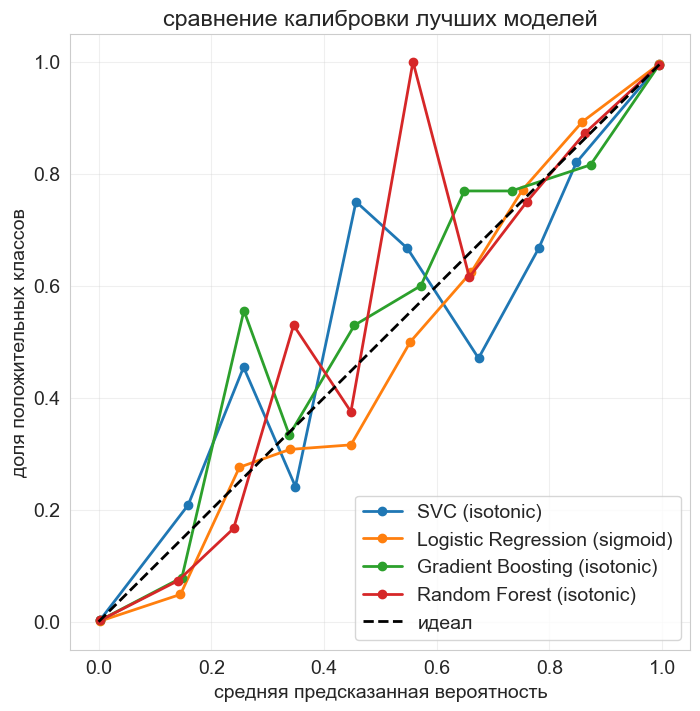

сравнение метрик калибровки:
sigmoid_svc (sigmoid): ece = 0.0028, brier = 0.0082
sigmoid_lr (sigmoid): ece = 0.0034, brier = 0.0087
sigmoid_gb (sigmoid): ece = 0.0035, brier = 0.0083
sigmoid_rf (sigmoid): ece = 0.0026, brier = 0.0084
isotonic_svc (isotonic): ece = 0.0021, brier = 0.0082
isotonic_lr (isotonic): ece = 0.0022, brier = 0.0088
isotonic_gb (isotonic): ece = 0.0023, brier = 0.0083
isotonic_rf (isotonic): ece = 0.0021, brier = 0.0081


In [46]:
plt.figure(figsize=(8, 8))
models_to_plot = [
    ('SVC (isotonic)', isotonic_svc_pred),
    ('Logistic Regression (sigmoid)', sigmoid_lr_pred),
    ('Gradient Boosting (isotonic)', isotonic_gb_pred),
    ('Random Forest (isotonic)', isotonic_rf_pred)
]

for name, pred in models_to_plot:
    frac_pos, mean_pred = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o', label=name, linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='идеал', linewidth=2)
plt.xlabel('средняя предсказанная вероятность')
plt.ylabel('доля положительных классов')
plt.title('сравнение калибровки лучших моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("сравнение метрик калибровки:")
print(f"sigmoid_svc (sigmoid): ece = {calculate_ece(y_test, sigmoid_svc_pred):.4f}, brier = {brier_score_loss(y_test, sigmoid_svc_pred):.4f}")
print(f"sigmoid_lr (sigmoid): ece = {calculate_ece(y_test, sigmoid_lr_pred):.4f}, brier = {brier_score_loss(y_test, sigmoid_lr_pred):.4f}")
print(f"sigmoid_gb (sigmoid): ece = {calculate_ece(y_test, sigmoid_gb_pred):.4f}, brier = {brier_score_loss(y_test, sigmoid_gb_pred):.4f}")
print(f"sigmoid_rf (sigmoid): ece = {calculate_ece(y_test, sigmoid_rf_pred):.4f}, brier = {brier_score_loss(y_test, sigmoid_rf_pred):.4f}")
print(f"isotonic_svc (isotonic): ece = {calculate_ece(y_test, isotonic_svc_pred):.4f}, brier = {brier_score_loss(y_test, isotonic_svc_pred):.4f}")
print(f"isotonic_lr (isotonic): ece = {calculate_ece(y_test, isotonic_lr_pred):.4f}, brier = {brier_score_loss(y_test, isotonic_lr_pred):.4f}")
print(f"isotonic_gb (isotonic): ece = {calculate_ece(y_test, isotonic_gb_pred):.4f}, brier = {brier_score_loss(y_test, isotonic_gb_pred):.4f}")
print(f"isotonic_rf (isotonic): ece = {calculate_ece(y_test, isotonic_rf_pred):.4f}, brier = {brier_score_loss(y_test, isotonic_rf_pred):.4f}")

Случайный лес с изотонической калибровкой (isotonic_rf) показал наилучшие метрики.

*Какой выбрать далее?*

Если важна максимальная калибровка — выбираем случайный лес с изотонической калибровкой. Если важна простота и интерпретируемость — логистическую регрессию (она уже хорошо откалибрована без дополнительных сложностей).

Больше информации - в [отличном туториале](https://classifier-calibration.github.io/ecml-pkdd-2020-tutorial/) и [материалах Дьяконова](https://web.archive.org/web/20240315204907/https://alexanderdyakonov.wordpress.com/2020/03/27/%D0%BF%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0-%D0%BA%D0%B0%D0%BB%D0%B8%D0%B1%D1%80%D0%BE%D0%B2%D0%BA%D0%B8-%D1%83%D0%B2%D0%B5%D1%80%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D0%B8/).